In [4]:
import pandas as pd
import pickle
import matplotlib

from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader

## Dataset Paths

In [5]:
FAQ_PATH = "../data/merged_customer_support_dataset.csv"
PDF_PATH = "../data/company_policies.pdf"

In [6]:
faq_df = pd.read_csv(FAQ_PATH)
print("FAQ Dataset Loaded Successfully")
faq_df.head()

FAQ Dataset Loaded Successfully


,category,question,answer,source,id
0,Order Tracking,Can I track multiple orders?,"Yes, each order has its own tracking informati...",faq,NaN
1,Order Tracking,Why hasn't my order shipped?,Orders are usually processed within 24 hours. ...,faq,NaN
2,Order Tracking,Where is my order?,You can track your order from the 'My Orders' ...,faq,NaN
3,Order Tracking,Can I track multiple orders?,"Yes, each order has its own tracking informati...",faq,NaN
4,Order Tracking,Why hasn't my order shipped?,Orders are usually processed within 24 hours. ...,faq,NaN


In [7]:
print("Dataset Shape:", faq_df.shape)
print()
faq_df.info()

Dataset Shape: (524, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  524 non-null    object
 1   question  524 non-null    object
 2   answer    504 non-null    object
 3   source    524 non-null    object
 4   id        24 non-null     object
dtypes: object(5)
memory usage: 20.6+ KB


In [8]:
faq_df.isnull().sum()

category      0
question      0
answer       20
source        0
id          500
dtype: int64

In [9]:
faq_df = faq_df.drop_duplicates()
faq_df = faq_df.dropna()
faq_df.reset_index(drop=True, inplace=True)
print("Cleaned Dataset Shape:", faq_df.shape)

Cleaned Dataset Shape: (4, 5)


## Convert FAQ Records into Documents

In [10]:
faq_documents = []

for _, row in faq_df.iterrows():

    text = f"""
Question:
{row['question']}

Answer:
{row['answer']}
"""

    doc = Document(

        page_content=text,

        metadata={
            "source": "FAQ",
            "category": row["category"]
        }
    )

    faq_documents.append(doc)

print("FAQ Documents Created:", len(faq_documents))

FAQ Documents Created: 4


In [11]:
faq_documents[0]

Document(metadata={'source': 'FAQ', 'category': 'Policy'}, page_content='\nQuestion:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.\n\nAnswer:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.\n')

In [12]:
loader = PyPDFLoader(PDF_PATH)
policy_documents = loader.load()
print("Policy Pages Loaded:", len(policy_documents))

Policy Pages Loaded: 1


In [13]:
policy_documents[0]

Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-16T07:19:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-07-16T07:19:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../data/company_policies.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Company Knowledge Base Policies\nReturn Policy\nProducts may be returned within 30 days of delivery. Items should be in original condition and\ninclude all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.\nRefunds are processed after inspection.\nRefund Policy\nRefunds are typically processed within 5 to 7 business days after return approval. Refunds are\nissued to the original payment method. Cash-on-delivery refunds are transferred to a registered\nbank account.\nShipping Policy\nStandard shipping takes 3 to 7 business days. Express shipping may be 

In [14]:
print(policy_documents[0].page_content[:1500])

Company Knowledge Base Policies
Return Policy
Products may be returned within 30 days of delivery. Items should be in original condition and
include all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.
Refunds are processed after inspection.
Refund Policy
Refunds are typically processed within 5 to 7 business days after return approval. Refunds are
issued to the original payment method. Cash-on-delivery refunds are transferred to a registered
bank account.
Shipping Policy
Standard shipping takes 3 to 7 business days. Express shipping may be available in select
locations. Delivery timelines may vary due to weather, holidays, or courier disruptions.
Payment Policy
Customers may pay using UPI, debit cards, credit cards, net banking, and supported digital wallets.
All payment transactions are encrypted and processed through secure gateways.
Cancellation Policy
Orders can be cancelled before shipment dispatch. Once an order is shipped, cancellation ma

## Combine Both Sources

In [15]:
documents = faq_documents + policy_documents

print("Total Documents:", len(documents))

Total Documents: 5


In [16]:
documents[0]

Document(metadata={'source': 'FAQ', 'category': 'Policy'}, page_content='\nQuestion:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.\n\nAnswer:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.\n')

In [17]:
documents[-1]

Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-16T07:19:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-07-16T07:19:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../data/company_policies.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Company Knowledge Base Policies\nReturn Policy\nProducts may be returned within 30 days of delivery. Items should be in original condition and\ninclude all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.\nRefunds are processed after inspection.\nRefund Policy\nRefunds are typically processed within 5 to 7 business days after return approval. Refunds are\nissued to the original payment method. Cash-on-delivery refunds are transferred to a registered\nbank account.\nShipping Policy\nStandard shipping takes 3 to 7 business days. Express shipping may be 

## Dataset Statistics

In [18]:
faq_count = len(faq_documents)
policy_count = len(policy_documents)
total = len(documents)
print(f"FAQ Documents     : {faq_count}")
print(f"Policy Documents  : {policy_count}")
print(f"Total Documents   : {total}")

FAQ Documents     : 4
Policy Documents  : 1
Total Documents   : 5


In [19]:
categories = faq_df["category"].value_counts()
categories

category
Policy    4
Name: count, dtype: int64

<Axes: xlabel='category'>

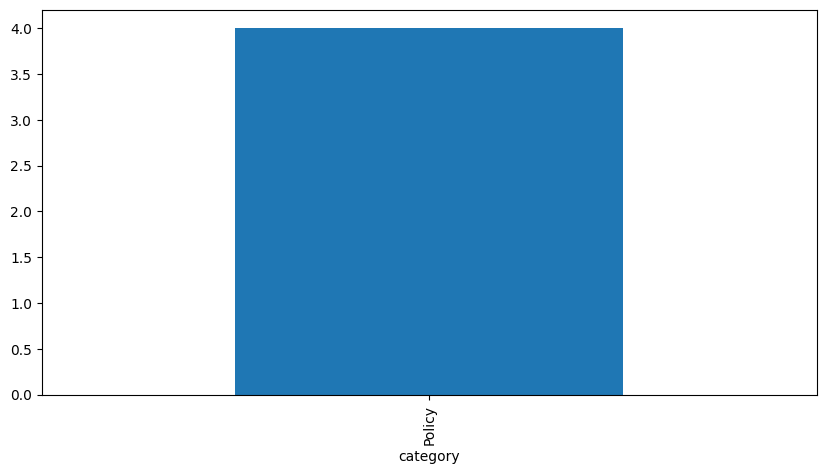

In [20]:
categories.plot.bar(figsize=(10,5))

## Save Documents

In [21]:
with open("../data/documents.pkl", "wb") as f:

    pickle.dump(documents, f)

print("Documents Saved Successfully")

Documents Saved Successfully


In [22]:
with open("../data/documents.pkl", "rb") as f:

    loaded_documents = pickle.load(f)

print("Loaded Documents:", len(loaded_documents))

Loaded Documents: 5


In [25]:
loaded_documents[4]

Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-16T07:19:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-07-16T07:19:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../data/company_policies.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Company Knowledge Base Policies\nReturn Policy\nProducts may be returned within 30 days of delivery. Items should be in original condition and\ninclude all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.\nRefunds are processed after inspection.\nRefund Policy\nRefunds are typically processed within 5 to 7 business days after return approval. Refunds are\nissued to the original payment method. Cash-on-delivery refunds are transferred to a registered\nbank account.\nShipping Policy\nStandard shipping takes 3 to 7 business days. Express shipping may be 